# NB09 — Supervised Prediction (Multi-Session, User 2)

Walk-forward cross-validation for ProtocolValue(t+1) prediction on user2 data.  
Mirrors NB03 but uses 11 sessions (58k rows) instead of a single session.  
**Reference:** User1 NB03 results: MAE=0.351, DirAcc=67.6%

In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import warnings
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('WARNING: lightgbm not installed. Install with: pip install lightgbm')

warnings.filterwarnings('ignore')

NEROES_PALETTE = {
    'bg':      '#0d1117',
    'surface': '#161b22',
    'cyan':    '#00c8ff',
    'teal':    '#00e5c3',
    'orange':  '#ff6b35',
    'yellow':  '#ffd700',
    'muted':   '#8b949e',
    'white':   '#e6edf3',
}

matplotlib.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        NEROES_PALETTE['muted'],
    'grid.alpha':        0.2,
    'figure.dpi':        120,
})

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## Section 1 — Load Features

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'user2_features.parquet')
with open(PROCESSED_DIR / 'user2_feature_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS   = meta['feature_cols']
TARGET         = meta['target_next']  # ProtocolValue_next
TRAIN_SESSIONS = meta['train_sessions']
TEST_SESSIONS  = meta['test_sessions']

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Feature cols: {len(FEATURE_COLS)}')
print(f'Train sessions: {TRAIN_SESSIONS}')
print(f'Test sessions:  {TEST_SESSIONS}')

# Remove rows where target is NaN (last row per session)
df_clean = df.dropna(subset=[TARGET] + FEATURE_COLS[:5]).copy()
print(f'\nAfter dropping NaN rows: {df_clean.shape[0]:,}')

Loaded: 50,194 rows × 82 cols
Feature cols: 59
Train sessions: ['session_1', 'session_3', 'session_4', 'session_5', 'session_6', 'session_7', 'session_8', 'session_9', 'session_10']
Test sessions:  ['session_12', 'session_13']

After dropping NaN rows: 50,183


## Section 2 — Train / Test Split (Walk-Forward)

Train sessions: 1,3,4,5,6,7,8,9,10 (all non-excluded sessions except the last two)  
Test sessions: 12,13 (held-out future sessions)

In [3]:
train_mask = df_clean['session_id'].isin(TRAIN_SESSIONS)
test_mask  = df_clean['session_id'].isin(TEST_SESSIONS)

# Only use game subsessions (ss > 0) for training — baseline rows are reference only
game_mask = df_clean['subsession'] > 0

train_df = df_clean[train_mask & game_mask]
test_df  = df_clean[test_mask  & game_mask]

print(f'Train set: {len(train_df):,} rows from {len(TRAIN_SESSIONS)} sessions')
print(f'Test set:  {len(test_df):,} rows from {len(TEST_SESSIONS)} sessions')

# Prepare feature matrices — fill remaining NaN from lags with 0 (session-start boundary)
X_train = train_df[FEATURE_COLS].fillna(0).values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].fillna(0).values
y_test  = test_df[TARGET].values

print(f'\nX_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

Train set: 37,963 rows from 9 sessions
Test set:  6,888 rows from 2 sessions

X_train: (37963, 59), y_train: (37963,)
X_test:  (6888, 59),  y_test:  (6888,)


## Section 3 — Baseline Models

In [4]:
# Persistence baseline: predict PV(t+1) = PV(t)
pv_now_test = test_df['ProtocolValue'].fillna(0).values
y_persist   = pv_now_test

# Mean baseline: predict constant = train mean
train_mean  = y_train.mean()
y_mean_bl   = np.full(len(y_test), train_mean)

def dir_acc(y_true, y_pred, y_prev):
    """Directional accuracy: fraction of steps where sign(pred-prev) == sign(true-prev)."""
    true_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return (true_dir[mask] == pred_dir[mask]).mean()

persist_mae   = mean_absolute_error(y_test, y_persist)
persist_dacc  = dir_acc(y_test, y_persist, pv_now_test)
mean_bl_mae   = mean_absolute_error(y_test, y_mean_bl)
mean_bl_dacc  = dir_acc(y_test, y_mean_bl, pv_now_test)

print('Baseline results:')
print(f'  Persistence  MAE={persist_mae:.4f}  DirAcc={100*persist_dacc:.1f}%')
print(f'  Mean-predict MAE={mean_bl_mae:.4f}  DirAcc={100*mean_bl_dacc:.1f}%')
print(f'  (User1 ref:  MAE=0.351,  DirAcc=67.6% with LightGBM)')

Baseline results:
  Persistence  MAE=0.4959  DirAcc=0.0%
  Mean-predict MAE=0.4094  DirAcc=71.3%
  (User1 ref:  MAE=0.351,  DirAcc=67.6% with LightGBM)


## Section 4 — LightGBM Model

In [5]:
if not HAS_LGBM:
    print('Skipping LightGBM — not installed.')
else:
    LGBM_PARAMS = {
        'objective':        'regression_l1',
        'n_estimators':     400,
        'learning_rate':    0.05,
        'num_leaves':       31,
        'min_child_samples': 20,
        'subsample':        0.8,
        'colsample_bytree': 0.8,
        'random_state':     42,
        'n_jobs':           -1,
        'verbose':          -1,
    }

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

    y_pred = model.predict(X_test)

    lgbm_mae  = mean_absolute_error(y_test, y_pred)
    lgbm_dacc = dir_acc(y_test, y_pred, pv_now_test)

    mae_improve = 100 * (persist_mae - lgbm_mae) / persist_mae

    print(f'LightGBM results on sessions 12–13:')
    print(f'  MAE      = {lgbm_mae:.4f}  ({mae_improve:+.1f}% vs persistence baseline)')
    print(f'  DirAcc   = {100*lgbm_dacc:.1f}%')
    print(f'  n_trees  = {model.best_iteration_ if hasattr(model,"best_iteration_") else LGBM_PARAMS["n_estimators"]}')
    print()
    print(f'  User1 reference: MAE=0.351, DirAcc=67.6%')
    print(f'  Persistence:     MAE={persist_mae:.4f}')

LightGBM results on sessions 12–13:
  MAE      = 0.3778  (+23.8% vs persistence baseline)
  DirAcc   = 72.6%
  n_trees  = 172

  User1 reference: MAE=0.351, DirAcc=67.6%
  Persistence:     MAE=0.4959


## Section 5 — Walk-Forward Cross-Validation

In [6]:
if not HAS_LGBM:
    print('Skipping walk-forward CV — LightGBM not installed.')
else:
    # Walk-forward: for each test session, train on all earlier sessions
    all_sessions_ordered = sorted(
        df_clean['session_id'].unique(),
        key=lambda x: int(x.split('_')[1])
    )
    # Only fold over sessions 3–13 (need at least session 1 as train)
    cv_sessions = [s for s in all_sessions_ordered
                   if int(s.split('_')[1]) >= 3]

    fold_results = []
    for test_sess in cv_sessions:
        test_num   = int(test_sess.split('_')[1])
        train_sids = [s for s in all_sessions_ordered
                      if int(s.split('_')[1]) < test_num]
        if len(train_sids) == 0:
            continue

        tr = df_clean[df_clean['session_id'].isin(train_sids) & (df_clean['subsession'] > 0)]
        te = df_clean[(df_clean['session_id'] == test_sess) & (df_clean['subsession'] > 0)]

        if len(te) < 10:
            continue

        Xtr = tr[FEATURE_COLS].fillna(0).values
        ytr = tr[TARGET].values
        Xte = te[FEATURE_COLS].fillna(0).values
        yte = te[TARGET].values
        pv_prev = te['ProtocolValue'].fillna(0).values

        m = lgb.LGBMRegressor(**{**LGBM_PARAMS, 'n_estimators': 200})
        m.fit(Xtr, ytr, callbacks=[lgb.log_evaluation(period=-1)])
        ypred = m.predict(Xte)

        fold_results.append({
            'test_session': test_sess,
            'n_train':      len(Xtr),
            'n_test':       len(Xte),
            'mae':          mean_absolute_error(yte, ypred),
            'dir_acc':      dir_acc(yte, ypred, pv_prev),
            'persist_mae':  mean_absolute_error(yte, pv_prev),
        })

    cv_df = pd.DataFrame(fold_results)
    print('Walk-Forward CV Results:')
    print(cv_df[['test_session','n_train','n_test','mae','dir_acc','persist_mae']].to_string(index=False))
    print(f'\nMean MAE:      {cv_df["mae"].mean():.4f} ± {cv_df["mae"].std():.4f}')
    print(f'Mean DirAcc:   {100*cv_df["dir_acc"].mean():.1f}% ± {100*cv_df["dir_acc"].std():.1f}%')
    print(f'Mean Persist:  {cv_df["persist_mae"].mean():.4f}')

Walk-Forward CV Results:
test_session  n_train  n_test      mae  dir_acc  persist_mae
   session_3     2684    3872 0.389348 0.712389     0.498550
   session_4     6556    3183 0.329553 0.744015     0.470426
   session_5     9739    7120 0.375674 0.725021     0.502094
   session_6    16859    3740 0.321369 0.739741     0.448697
   session_7    20599    4471 0.388634 0.724402     0.512033
   session_8    25070    3864 0.278667 0.746621     0.410001
   session_9    28934    3638 0.475465 0.692137     0.560405
  session_10    32572    5391 0.346245 0.716956     0.454141
  session_12    37963    3499 0.349052 0.734009     0.479059
  session_13    41462    3389 0.409501 0.712197     0.513372

Mean MAE:      0.3664 ± 0.0544
Mean DirAcc:   72.5% ± 1.7%
Mean Persist:  0.4849


## Section 6 — Feature Importance

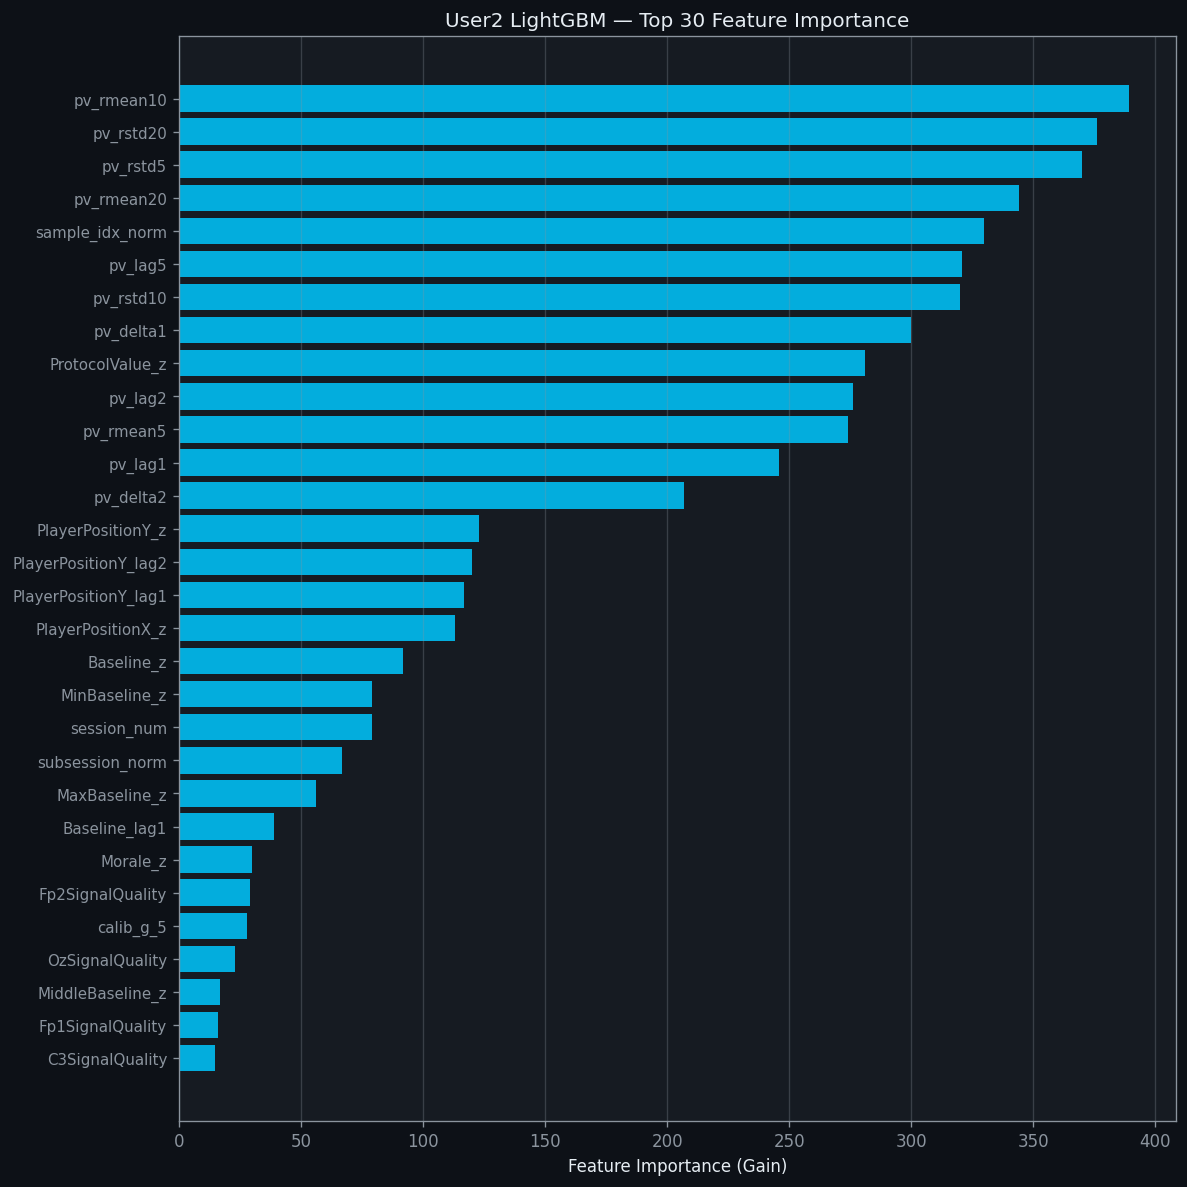

Saved: u2_lgbm_importance.png

Top 10 features:
  pv_rmean10: 389.0
  pv_rstd20: 376.0
  pv_rstd5: 370.0
  pv_rmean20: 344.0
  sample_idx_norm: 330.0
  pv_lag5: 321.0
  pv_rstd10: 320.0
  pv_delta1: 300.0
  ProtocolValue_z: 281.0
  pv_lag2: 276.0


In [7]:
if not HAS_LGBM:
    print('Skipping — LightGBM not installed.')
else:
    importance = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    top30 = importance.head(30)

    fig, ax = plt.subplots(figsize=(10, 10), facecolor=NEROES_PALETTE['bg'])
    bars = ax.barh(
        range(len(top30)),
        top30.values[::-1],
        color=NEROES_PALETTE['cyan'],
        alpha=0.85,
    )
    ax.set_yticks(range(len(top30)))
    ax.set_yticklabels(top30.index[::-1], fontsize=9)
    ax.set_xlabel('Feature Importance (Gain)', color=NEROES_PALETTE['white'])
    ax.set_title('User2 LightGBM — Top 30 Feature Importance', color=NEROES_PALETTE['white'])
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'u2_lgbm_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: u2_lgbm_importance.png')
    print('\nTop 10 features:')
    for name, val in top30.head(10).items():
        print(f'  {name}: {val:.1f}')

## Section 7 — Prediction Visualisation

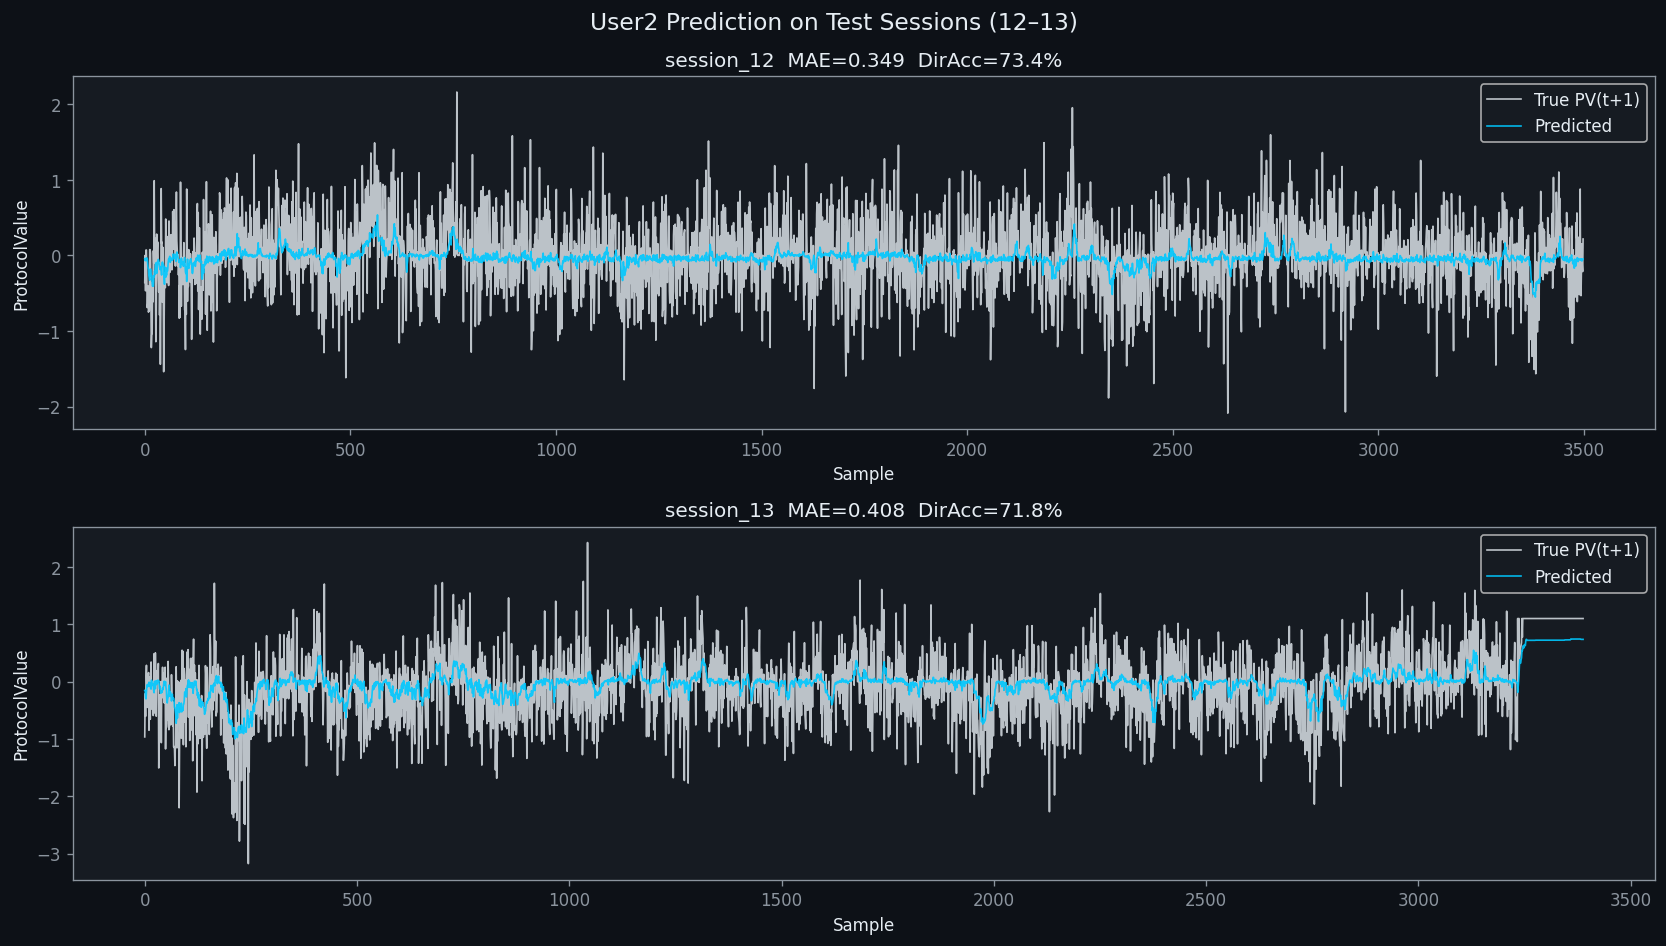

Saved: u2_prediction_vs_true.png


In [8]:
if not HAS_LGBM:
    print('Skipping — LightGBM not installed.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), facecolor=NEROES_PALETTE['bg'])

    for ax_idx, (sess, ax) in enumerate(zip(TEST_SESSIONS, axes)):
        sess_mask = (test_df['session_id'] == sess) & (test_df['subsession'] > 0)
        if sess_mask.sum() == 0:
            continue
        Xs  = test_df.loc[sess_mask, FEATURE_COLS].fillna(0).values
        ys  = test_df.loc[sess_mask, TARGET].values
        yps = model.predict(Xs)

        ax.plot(ys,  color=NEROES_PALETTE['white'], lw=1.0, alpha=0.8, label='True PV(t+1)')
        ax.plot(yps, color=NEROES_PALETTE['cyan'],  lw=1.0, alpha=0.9, label='Predicted')
        sess_mae  = mean_absolute_error(ys, yps)
        pv_prev_s = test_df.loc[sess_mask, 'ProtocolValue'].fillna(0).values
        sess_dacc = dir_acc(ys, yps, pv_prev_s)
        ax.set_title(f'{sess}  MAE={sess_mae:.3f}  DirAcc={100*sess_dacc:.1f}%',
                     color=NEROES_PALETTE['white'])
        ax.set_xlabel('Sample', color=NEROES_PALETTE['white'])
        ax.set_ylabel('ProtocolValue', color=NEROES_PALETTE['white'])
        ax.legend(facecolor=NEROES_PALETTE['surface'])

    fig.suptitle('User2 Prediction on Test Sessions (12–13)',
                 color=NEROES_PALETTE['white'], fontsize=14)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'u2_prediction_vs_true.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: u2_prediction_vs_true.png')

## Section 8 — User1 vs User2 Comparison Dashboard


=== User1 vs User2 Prediction Comparison ===
         Metric   User1     User2    Delta
            MAE   0.351  0.377841    0.027
     DirAcc (%)  67.600 72.649573    5.050
Persistence MAE   0.478  0.495942    0.018
       Features 246.000 59.000000 -187.000


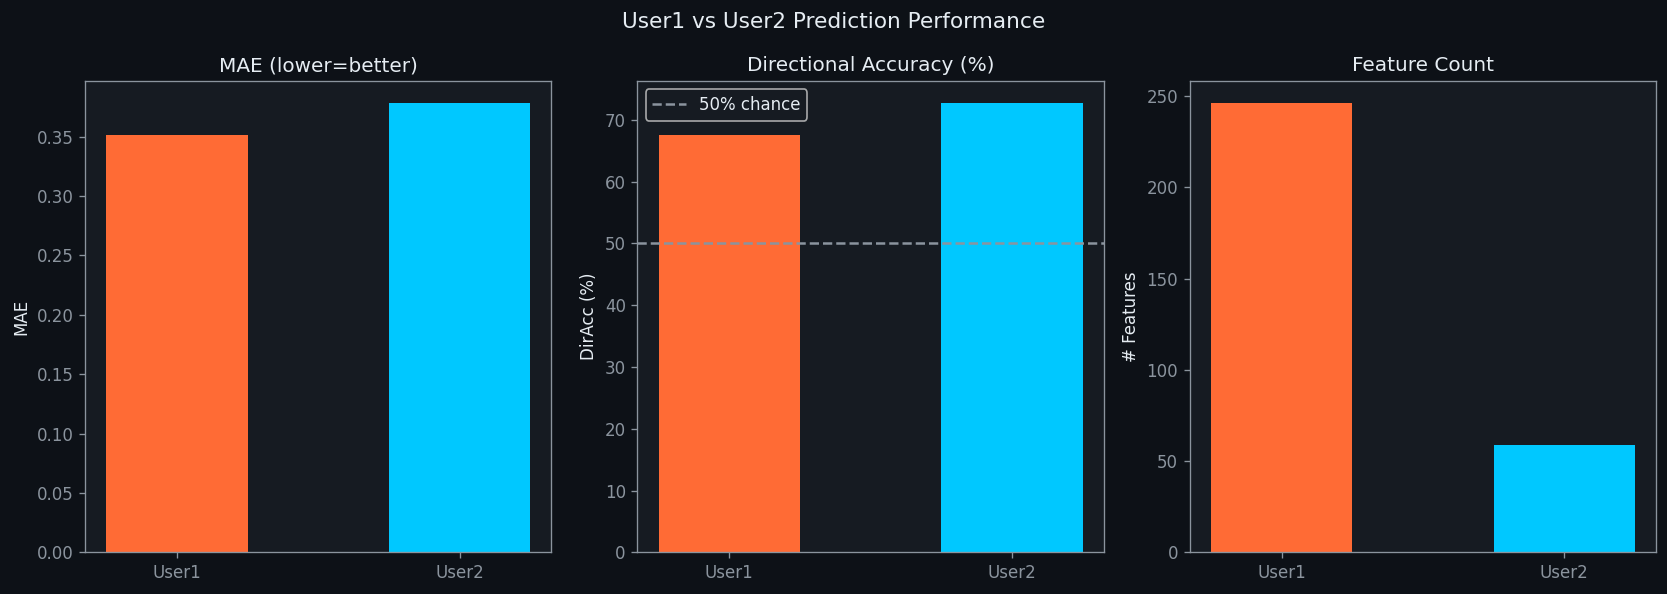

Saved: u2_prediction_comparison.png


In [9]:
if not HAS_LGBM:
    print('Skipping — LightGBM not installed.')
else:
    # User1 reference metrics from NB03
    U1_MAE     = 0.351
    U1_DACC    = 67.6
    U1_PERSIST = 0.478  # user1 persistence MAE

    U2_MAE     = lgbm_mae
    U2_DACC    = 100 * lgbm_dacc
    U2_PERSIST = persist_mae

    metrics = ['MAE', 'DirAcc (%)', 'Persistence MAE', 'Features']
    u1_vals = [U1_MAE, U1_DACC, U1_PERSIST, 246]
    u2_vals = [U2_MAE, U2_DACC, U2_PERSIST, meta['n_features']]

    comp_df = pd.DataFrame({'Metric': metrics, 'User1': u1_vals, 'User2': u2_vals})
    comp_df['Delta'] = (np.array(u2_vals) - np.array(u1_vals)).round(3)

    print('\n=== User1 vs User2 Prediction Comparison ===')
    print(comp_df.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor=NEROES_PALETTE['bg'])
    colors = [NEROES_PALETTE['orange'], NEROES_PALETTE['cyan']]
    labels = ['User1', 'User2']

    ax1, ax2, ax3 = axes

    ax1.bar(labels, [U1_MAE, U2_MAE], color=colors, width=0.5)
    ax1.set_title('MAE (lower=better)', color=NEROES_PALETTE['white'])
    ax1.set_ylabel('MAE', color=NEROES_PALETTE['white'])

    ax2.bar(labels, [U1_DACC, U2_DACC], color=colors, width=0.5)
    ax2.set_title('Directional Accuracy (%)', color=NEROES_PALETTE['white'])
    ax2.set_ylabel('DirAcc (%)', color=NEROES_PALETTE['white'])
    ax2.axhline(50, color=NEROES_PALETTE['muted'], ls='--', label='50% chance')
    ax2.legend(facecolor=NEROES_PALETTE['surface'])

    ax3.bar(labels, [246, meta['n_features']], color=colors, width=0.5)
    ax3.set_title('Feature Count', color=NEROES_PALETTE['white'])
    ax3.set_ylabel('# Features', color=NEROES_PALETTE['white'])

    fig.suptitle('User1 vs User2 Prediction Performance',
                 color=NEROES_PALETTE['white'], fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'u2_prediction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: u2_prediction_comparison.png')

## Section 9 — Save Model

In [10]:
if not HAS_LGBM:
    print('Skipping — LightGBM not installed.')
else:
    model_path = OUTPUTS_DIR / 'u2_lgbm_predictor.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({'model': model, 'feature_cols': FEATURE_COLS,
                     'mae': lgbm_mae, 'dir_acc': lgbm_dacc}, f)
    print(f'Saved: {model_path}')

    print('\n=== Final Summary ===')
    print(f'Model: LightGBM ({LGBM_PARAMS["n_estimators"]} trees)')
    print(f'Train: {len(train_df):,} samples | Test: {len(test_df):,} samples')
    print(f'MAE = {lgbm_mae:.4f}  (persistence = {persist_mae:.4f},  improve = {mae_improve:+.1f}%)')
    print(f'DirAcc = {100*lgbm_dacc:.1f}%')
    print(f'User1 reference: MAE=0.351, DirAcc=67.6%')

Saved: /home/bruno1008/neroes/neroes-neurofeedback/outputs/u2_lgbm_predictor.pkl

=== Final Summary ===
Model: LightGBM (400 trees)
Train: 37,963 samples | Test: 6,888 samples
MAE = 0.3778  (persistence = 0.4959,  improve = +23.8%)
DirAcc = 72.6%
User1 reference: MAE=0.351, DirAcc=67.6%
